# Step 1: Flight Data Ingestion and Validation
This notebook reviews the Step 1 pipeline that harvests North Atlantic candidates and saves fusion-ready flights.
Use it to inspect saved outputs or rerun ingestion with a controlled window.


## Step 1 Rule and Demo Flow
A flight is kept only when the ADS-B context brackets a real oceanic gap and ADS-C covers that gap cleanly.
The cells below show the filter, the saved run, and the merged master dataset.


In [ ]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "aero_fusion").exists():
            return candidate
    raise RuntimeError("Could not locate the project root containing src/aero_fusion.")


def resolve_artifact_path(saved_path: str | Path, *, output_root: Path | None = None, master_root: Path | None = None) -> Path:
    candidate = Path(saved_path)
    if candidate.exists():
        return candidate

    parts = candidate.as_posix().split("/")

    if "flights" in parts:
        flights_idx = parts.index("flights")
        suffix_parts = parts[flights_idx:]

        if output_root is not None:
            resolved = output_root.joinpath(*suffix_parts)
            if resolved.exists():
                return resolved

        if master_root is not None:
            resolved = master_root.joinpath(*suffix_parts)
            if resolved.exists():
                return resolved

    if "artifacts" in parts:
        artifacts_idx = parts.index("artifacts")
        relative_parts = parts[artifacts_idx + 1:]
        resolved = PROJECT_ROOT / "artifacts" / Path(*relative_parts)
        if resolved.exists():
            return resolved

    return candidate


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import aero_fusion.ingest as ingest_module
import aero_fusion.step1_master as step1_master_module
importlib.reload(ingest_module)
importlib.reload(step1_master_module)

from aero_fusion.ingest import IngestConfig, RunWindow, inspect_source_columns, run_step1_ingestion
from aero_fusion.plotting import (
    plot_adsc_point_count_hist,
    plot_boundary_speed_hist,
    plot_gap_duration_hist,
    plot_stitched_route,
    plot_time_progress,
    plot_validated_flights_by_day,
)
from aero_fusion.step1_master import build_step1_master, default_raw_runs
from aero_fusion.trino_io import TrinoConfig, get_connection
from aero_fusion.validation import ValidationThresholds


## Configure
Set the run window and execution mode here.
For review or presentation, keep `BUILD_FROM_SOURCE = False` and use the saved outputs.


In [ ]:
# Notebook config
TRINO_HOST = "trino.opensky-network.org"
TRINO_PORT = 443
TRINO_HTTP_SCHEME = "https"
TRINO_VERIFY = True
TRINO_USER = "johnelhachem"


SMOKE_TEST_START = "2025-05-01"
SMOKE_TEST_END   = "2025-06-01"
FULL_START = "2025-03-01"
FULL_END = "2025-03-01"

# Main notebook mode:
# - BUILD_FROM_SOURCE = False -> presentation / read-only mode
#   Uses saved local outputs, skips Trino fetch, and skips master rebuild.
# - BUILD_FROM_SOURCE = True -> build mode
#   Allows rebuilding Step 1 outputs from source data.
BUILD_FROM_SOURCE = False
RUN_MODE = "full"

OUTPUT_ROOT = PROJECT_ROOT / "artifacts" / "raw_data" / "step1_raw_2025-03-01_to_2025-04-01"
MASTER_ROOT = PROJECT_ROOT / "artifacts" / "step1_dataset"

ADSC_SEGMENT_GAP_MINUTES = 90
MIN_ADSC_POINTS = 2
PROCESSING_CONTEXT_HOURS = 4
ADSB_CONTEXT_MINUTES = 180
MAX_BOUNDARY_SPEED_KTS = 750.0
MAX_INTERNAL_SPEED_KTS = 700.0

ICAO_BATCH_SIZE = 200
MAX_SEGMENTS_TO_VALIDATE = None
USE_ADSC_CACHE = False

# Pre-filter thresholds — applied before any ADS-B query is issued.
MIN_GAP_DURATION_MINUTES = 120.0   # minimum ADS-C gap to qualify as oceanic
MIN_ANCHOR_DISTANCE_KM   = 1500.0  # minimum anchor-to-anchor great-circle distance
SHANWICK_BBOX = (35.0, 70.0, -60.0, 20.0)  # (lat_min, lat_max, lon_min, lon_max)

run_window = (
    RunWindow(start=SMOKE_TEST_START, end=SMOKE_TEST_END)
    if RUN_MODE.lower() == "smoke"
    else RunWindow(start=FULL_START, end=FULL_END)
)

summary_path = OUTPUT_ROOT / "validated_fusion_candidates.parquet"
local_summary_available = summary_path.exists()
effective_run_trino = BUILD_FROM_SOURCE

trino_config = TrinoConfig(
    host=TRINO_HOST,
    port=TRINO_PORT,
    http_scheme=TRINO_HTTP_SCHEME,
    verify=TRINO_VERIFY,
    user=TRINO_USER,
)

ingest_config = IngestConfig(
    run_window=run_window,
    output_root=OUTPUT_ROOT,
    adsc_segment_gap_minutes=ADSC_SEGMENT_GAP_MINUTES,
    min_adsc_points=MIN_ADSC_POINTS,
    processing_context_hours=PROCESSING_CONTEXT_HOURS,
    adsb_context_minutes=ADSB_CONTEXT_MINUTES,
    icao_batch_size=ICAO_BATCH_SIZE,
    max_segments_to_validate=MAX_SEGMENTS_TO_VALIDATE,
    use_adsc_cache=USE_ADSC_CACHE,
    min_gap_duration_minutes=MIN_GAP_DURATION_MINUTES,
    min_anchor_distance_km=MIN_ANCHOR_DISTANCE_KM,
    shanwick_bbox=SHANWICK_BBOX,
    validation_thresholds=ValidationThresholds(
        max_boundary_speed_kts=MAX_BOUNDARY_SPEED_KTS,
        max_internal_speed_kts=MAX_INTERNAL_SPEED_KTS,
    ),
)

pd.DataFrame(
    {
        "setting": [
            "prepared_by",
            "build_from_source",
            "local_summary_available",
            "effective_run_trino",
            "run_mode",
            "start_date",
            "end_date",
            "output_root",
            "master_root",
            "trino_host",
            "trino_user",
            "adsb_context_minutes",
            "min_gap_duration_minutes",
            "min_anchor_distance_km",
            "shanwick_bbox",
            "max_segments_to_validate",
        ],
        "value": [
            "John El Hachem",
            BUILD_FROM_SOURCE,
            local_summary_available,
            effective_run_trino,
            RUN_MODE,
            run_window.start,
            run_window.end,
            str(OUTPUT_ROOT),
            str(MASTER_ROOT),
            TRINO_HOST,
            TRINO_USER,
            ADSB_CONTEXT_MINUTES,
            MIN_GAP_DURATION_MINUTES,
            MIN_ANCHOR_DISTANCE_KM,
            str(SHANWICK_BBOX),
            MAX_SEGMENTS_TO_VALIDATE,
        ],
    }
).style.hide(axis="index")

setting,value
prepared_by,John El Hachem
build_from_source,False
local_summary_available,True
effective_run_trino,False
run_mode,full
start_date,2025-01-01
end_date,2025-02-01
output_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\raw_data\step1_raw_2025-03-01_to_2025-04-01
master_root,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step1_dataset
trino_host,trino.opensky-network.org


## Raw Run
This section loads the selected Step 1 run from `OUTPUT_ROOT`.
In review mode it reads the saved catalog only; in build mode it reruns ingestion and refreshes the local artifacts.


In [3]:
summary_df = pd.DataFrame()
source_column_report = pd.DataFrame()

def _resolve_artifact_path_local(saved_path: str | Path, *, output_root: Path | None = None, master_root: Path | None = None) -> Path:
    candidate = Path(saved_path)
    if candidate.exists():
        return candidate

    parts = candidate.as_posix().split("/")

    if "flights" in parts:
        flights_idx = parts.index("flights")
        suffix_parts = parts[flights_idx:]

        if output_root is not None:
            run_name = output_root.name if output_root.name.startswith("step1_raw_") else None
            if run_name is not None and run_name in parts:
                run_idx = parts.index(run_name)
                resolved = output_root.joinpath(*parts[run_idx + 1:])
            else:
                resolved = output_root.joinpath(*suffix_parts)
            if resolved.exists():
                return resolved

        if master_root is not None:
            resolved = master_root.joinpath(*suffix_parts)
            if resolved.exists():
                return resolved

    if "artifacts" in parts:
        artifacts_idx = parts.index("artifacts")
        relative_parts = parts[artifacts_idx + 1:]
        resolved = PROJECT_ROOT / "artifacts" / Path(*relative_parts)
        if resolved.exists():
            return resolved

    return candidate


def _normalize_path_columns(frame: pd.DataFrame, *, output_root: Path, master_root: Path) -> pd.DataFrame:
    if frame.empty:
        return frame

    normalized = frame.copy()
    path_columns = [col for col in normalized.columns if col.endswith("_path")]
    for col in path_columns:
        normalized[col] = normalized[col].map(
            lambda value: str(_resolve_artifact_path_local(value, output_root=output_root, master_root=master_root)) if pd.notna(value) else value
        )
    return normalized

if effective_run_trino:
    print(f"Running live Trino ingestion for {run_window.start} to {run_window.end}")
    connection = get_connection(trino_config)
    try:
        source_columns = inspect_source_columns(connection, trino_config)
        source_column_report = pd.DataFrame(
            [
                {"table": "adsc", "field": field, "column": None if spec is None else spec.name, "type": None if spec is None else spec.trino_type}
                for field, spec in source_columns.adsc.items()
            ]
            + [
                {"table": "flights_data4", "field": field, "column": None if spec is None else spec.name, "type": None if spec is None else spec.trino_type}
                for field, spec in source_columns.flights.items()
            ]
            + [
                {"table": "state_vectors_data4", "field": field, "column": None if spec is None else spec.name, "type": None if spec is None else spec.trino_type}
                for field, spec in source_columns.adsb.items()
            ]
        )
        display(source_column_report)

        summary_df = run_step1_ingestion(
            connection=connection,
            trino_config=trino_config,
            ingest_config=ingest_config,
        )
    finally:
        connection.close()
elif local_summary_available:
    print(f"Using saved local Step 1 summary from {summary_path}")
    summary_df = pd.read_parquet(summary_path)
else:
    print("No local Step 1 summary was found for the selected OUTPUT_ROOT.")
    print("Set BUILD_FROM_SOURCE = True if you want to build this raw run from Trino.")

summary_df = _normalize_path_columns(summary_df, output_root=OUTPUT_ROOT, master_root=MASTER_ROOT)

summary_df.head(10)


Using saved local Step 1 summary from C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\raw_data\step1_raw_2025-03-01_to_2025-04-01\validated_fusion_candidates.parquet


,segment_id,processing_day,icao24,segment_start_time,segment_end_time,gap_duration_minutes,adsc_point_count,segment_callsign,flight_callsign,flight_start_time,...,before_boundary_speed_kts,after_boundary_speed_kts,max_internal_speed_kts,median_internal_speed_kts,artifact_dir,adsc_path,adsb_before_path,adsb_after_path,stitched_minimal_path,metadata_path
0,20250301_3c4b2a_173209_195634,2025-03-01,3c4b2a,2025-03-01 17:32:09,2025-03-01 19:56:34,144.416667,6,None,DLH402,2025-03-01 15:18:11,...,614.243525,393.554032,456.046672,412.175354,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1,20250301_4ba959_190800_215049,2025-03-01,4ba959,2025-03-01 19:08:00,2025-03-01 21:50:49,162.816667,5,None,THY1,2025-03-01 15:02:04,...,516.287569,396.552277,498.902990,449.467568,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
2,20250302_89640a_163509_184511,2025-03-02,89640a,2025-03-02 16:35:09,2025-03-02 18:45:11,130.033333,7,None,ETD11B,2025-03-02 08:35:17,...,562.098036,396.391768,474.641881,436.204230,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
3,20250302_0201a4_194551_215039,2025-03-02,0201a4,2025-03-02 19:45:51,2025-03-02 21:50:39,124.800000,4,None,RAM208M,2025-03-02 06:41:22,...,702.153576,401.687338,480.920164,460.550761,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
4,20250304_4ba953_191906_215613,2025-03-04,4ba953,2025-03-04 19:19:06,2025-03-04 21:56:13,157.116667,4,None,THY17W,2025-03-04 15:11:09,...,705.333625,451.305720,444.058603,427.046903,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
5,20250304_4bb144_192206_215822,2025-03-04,4bb144,2025-03-04 19:22:06,2025-03-04 21:58:22,156.266667,5,None,THY31K,2025-03-04 15:01:13,...,533.100902,452.584467,441.589074,418.081020,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
6,20250304_a92d6d_201021_222220,2025-03-04,a92d6d,2025-03-04 20:10:21,2025-03-04 22:22:20,131.983333,6,None,UAL933,2025-03-04 18:19:12,...,708.811298,445.029115,451.760626,410.659093,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
7,20250310_400685_181456_204133,2025-03-10,400685,2025-03-10 18:14:56,2025-03-10 20:41:33,146.616667,13,None,BAW19N,2025-03-10 16:49:15,...,630.725341,412.215663,519.612150,487.093385,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Deskt

In [4]:
if summary_df.empty:
    print("No raw Step 1 summary is available for the selected OUTPUT_ROOT.")
else:
    overview = pd.DataFrame(
        {
            "metric": [
                "validated_segments",
                "unique_icao24",
                "start_date",
                "end_date",
                "median_gap_minutes",
                "median_adsc_points",
            ],
            "value": [
                int(len(summary_df)),
                int(summary_df["icao24"].nunique()),
                str(pd.to_datetime(summary_df["segment_start_time"]).min()),
                str(pd.to_datetime(summary_df["segment_end_time"]).max()),
                round(float(summary_df["gap_duration_minutes"].median()), 2),
                round(float(summary_df["adsc_point_count"].median()), 2),
            ],
        }
    )
    display(HTML("<h3 style='margin:0 0 8px 0;'>Raw Step 1 Summary</h3>"))
    display(overview.style.hide(axis="index"))
    display(HTML("<h4 style='margin:16px 0 8px 0;'>Sample validated segments</h4>"))
    display(summary_df.sort_values(["processing_day", "segment_start_time"]).head(20))
    display(HTML("<h4 style='margin:16px 0 8px 0;'>Validated segments per day</h4>"))
    display(summary_df.groupby("processing_day").size().rename("validated_segments").reset_index())


metric,value
validated_segments,128
unique_icao24,89
start_date,2025-03-01 17:32:09
end_date,2025-03-29 20:40:19
median_gap_minutes,144.670000
median_adsc_points,14.000000


,segment_id,processing_day,icao24,segment_start_time,segment_end_time,gap_duration_minutes,adsc_point_count,segment_callsign,flight_callsign,flight_start_time,...,before_boundary_speed_kts,after_boundary_speed_kts,max_internal_speed_kts,median_internal_speed_kts,artifact_dir,adsc_path,adsb_before_path,adsb_after_path,stitched_minimal_path,metadata_path
0,20250301_3c4b2a_173209_195634,2025-03-01,3c4b2a,2025-03-01 17:32:09,2025-03-01 19:56:34,144.416667,6,None,DLH402,2025-03-01 15:18:11,...,614.243525,393.554032,456.046672,412.175354,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1,20250301_4ba959_190800_215049,2025-03-01,4ba959,2025-03-01 19:08:00,2025-03-01 21:50:49,162.816667,5,None,THY1,2025-03-01 15:02:04,...,516.287569,396.552277,498.902990,449.467568,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
2,20250302_89640a_163509_184511,2025-03-02,89640a,2025-03-02 16:35:09,2025-03-02 18:45:11,130.033333,7,None,ETD11B,2025-03-02 08:35:17,...,562.098036,396.391768,474.641881,436.204230,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
3,20250302_0201a4_194551_215039,2025-03-02,0201a4,2025-03-02 19:45:51,2025-03-02 21:50:39,124.800000,4,None,RAM208M,2025-03-02 06:41:22,...,702.153576,401.687338,480.920164,460.550761,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
4,20250304_4ba953_191906_215613,2025-03-04,4ba953,2025-03-04 19:19:06,2025-03-04 21:56:13,157.116667,4,None,THY17W,2025-03-04 15:11:09,...,705.333625,451.305720,444.058603,427.046903,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
5,20250304_4bb144_192206_215822,2025-03-04,4bb144,2025-03-04 19:22:06,2025-03-04 21:58:22,156.266667,5,None,THY31K,2025-03-04 15:01:13,...,533.100902,452.584467,441.589074,418.081020,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
6,20250304_a92d6d_201021_222220,2025-03-04,a92d6d,2025-03-04 20:10:21,2025-03-04 22:22:20,131.983333,6,None,UAL933,2025-03-04 18:19:12,...,708.811298,445.029115,451.760626,410.659093,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
7,20250310_400685_181456_204133,2025-03-10,400685,2025-03-10 18:14:56,2025-03-10 20:41:33,146.616667,13,None,BAW19N,2025-03-10 16:49:15,...,630.725341,412.215663,519.612150,487.093385,C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,C:\Users\ANTOINE\OneDrive\Deskt

,processing_day,validated_segments
0,2025-03-01,2
1,2025-03-02,2
2,2025-03-04,3
3,2025-03-10,3
4,2025-03-11,5
5,2025-03-12,3
6,2025-03-13,12
7,2025-03-14,7
8,2025-03-15,3
9,2025-03-16,2


## Raw Run Visuals
These figures summarize the currently selected raw Step 1 run.
They are the fastest way to verify candidate volume, timing, and route coverage.


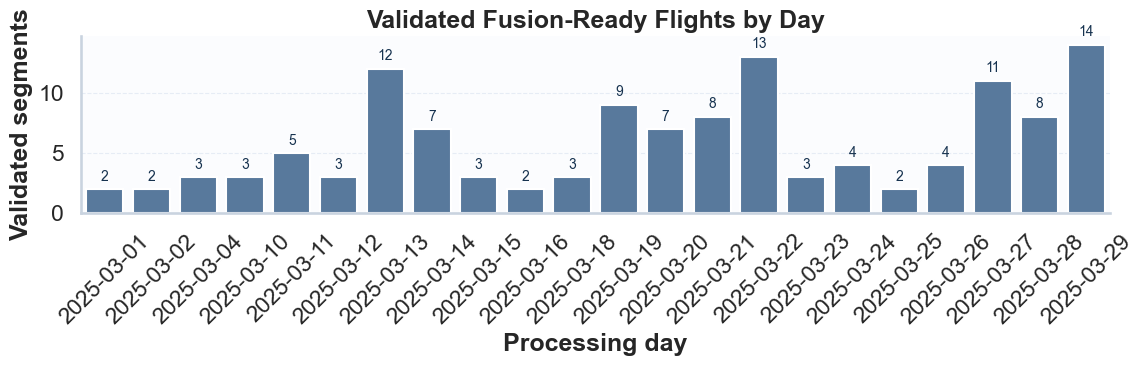

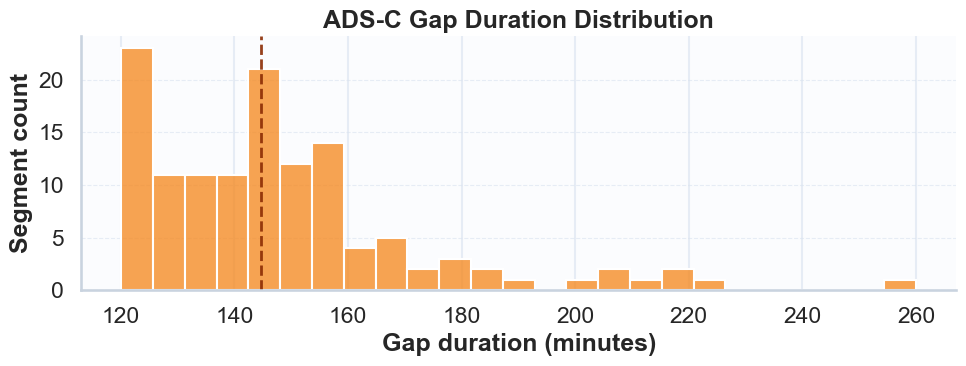

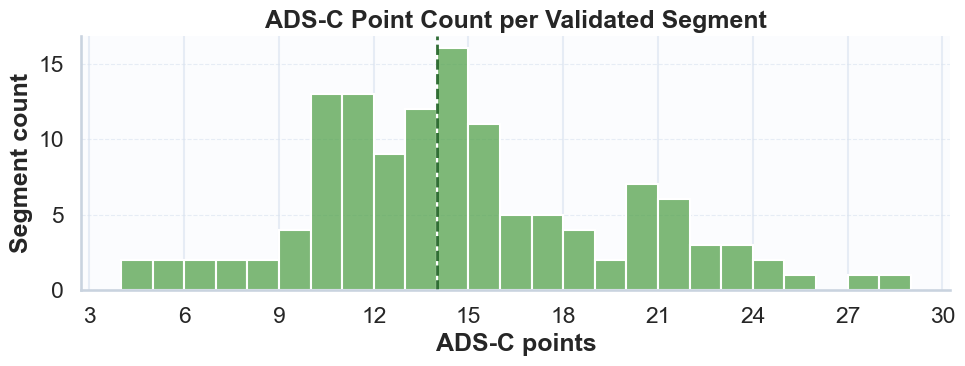

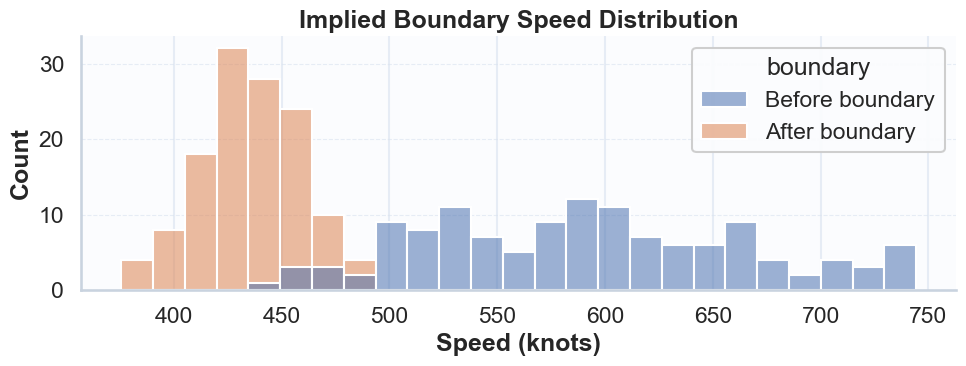

In [5]:
if summary_df.empty:
    print("No plots to render because no validated segments were found.")
else:
    plot_validated_flights_by_day(summary_df)
    plt.show()

    plot_gap_duration_hist(summary_df)
    plt.show()

    plot_adsc_point_count_hist(summary_df)
    plt.show()

    plot_boundary_speed_hist(summary_df)
    plt.show()


## Example Stitched Routes
These examples show the saved flights that survived Step 1 validation.
Use them to confirm that the ADS-B context and ADS-C gap coverage line up as expected.


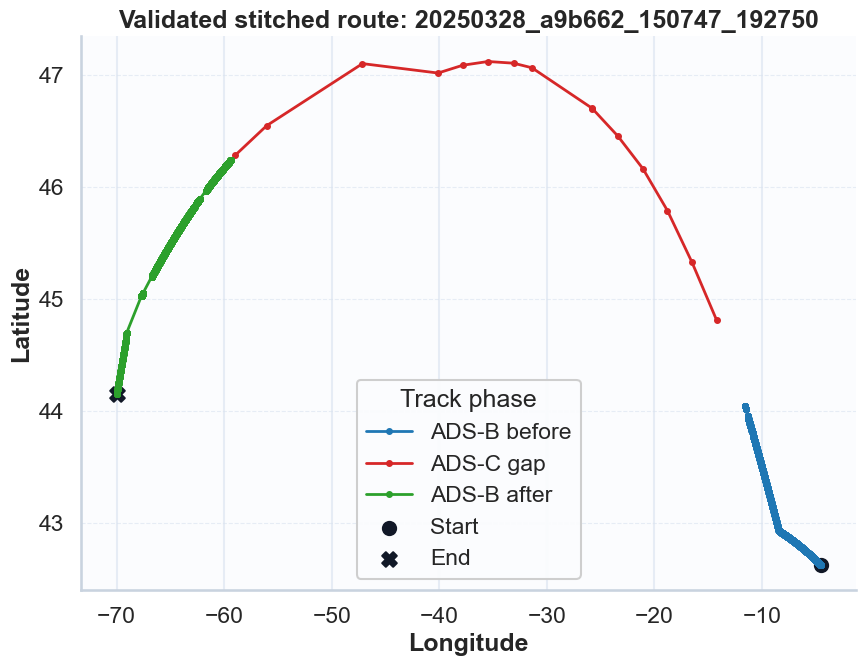

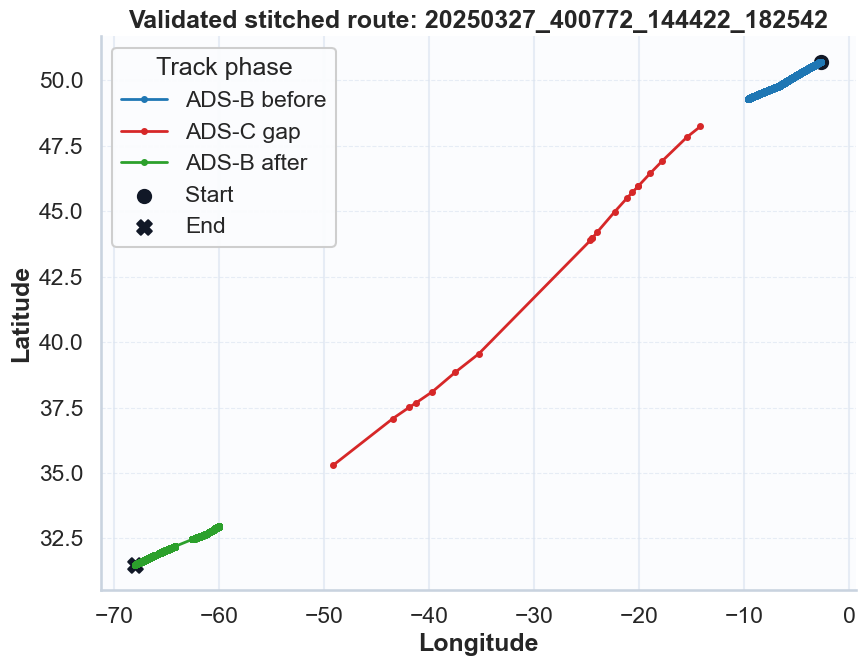

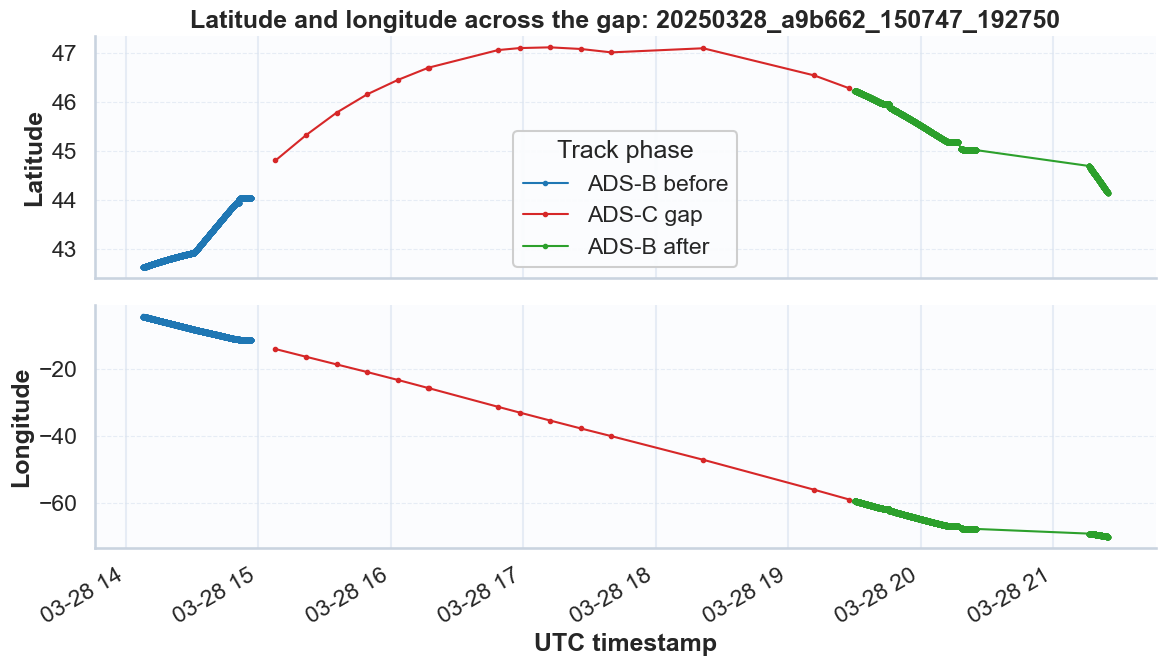

In [6]:
if summary_df.empty:
    print("No example routes available.")
else:
    example_rows = summary_df.sort_values(["gap_duration_minutes", "adsc_point_count"], ascending=[False, False]).head(2)
    for row in example_rows.itertuples(index=False):
        stitched_df = pd.read_parquet(row.stitched_minimal_path)
        plot_stitched_route(stitched_df, title=f"Validated stitched route: {row.segment_id}")
        plt.show()

    first_row = example_rows.iloc[0]
    adsc_df = pd.read_parquet(first_row.adsc_path)
    adsb_before_df = pd.read_parquet(first_row.adsb_before_path)
    adsb_after_df = pd.read_parquet(first_row.adsb_after_path)
    plot_time_progress(
        adsb_before=adsb_before_df,
        adsc_gap=adsc_df,
        adsb_after=adsb_after_df,
        title=f"Latitude and longitude across the gap: {first_row.segment_id}",
    )
    plt.show()


## Build the Master Dataset
This step merges the preserved raw runs under `artifacts/raw_data/step1_raw_*` into one deduplicated master catalog.
Keep `BUILD_FROM_SOURCE = False` unless you intentionally want to rebuild the Step 1 master dataset.


In [7]:
import json

RAW_RUNS = default_raw_runs(PROJECT_ROOT)
raw_run_df = pd.DataFrame(
    {
        "raw_run_name": [run.name for run in RAW_RUNS],
        "raw_run_path": [str(run.path.relative_to(PROJECT_ROOT)) for run in RAW_RUNS],
    }
)
display(raw_run_df)

master_root = MASTER_ROOT
master_catalog_path = master_root / "catalog" / "master_flights_catalog.parquet"
integrity_issues_path = master_root / "catalog" / "integrity_issues.parquet"
duplicates_path = master_root / "catalog" / "duplicates.parquet"
audit_summary_path = master_root / "audit_summary.json"

master_exists = master_catalog_path.exists() and integrity_issues_path.exists() and duplicates_path.exists()
use_existing_master = (not BUILD_FROM_SOURCE) and master_exists

if use_existing_master:
    print(f"Using existing Step 1 master dataset from {master_root}")
    if audit_summary_path.exists():
        master_summary = json.loads(audit_summary_path.read_text(encoding="utf-8"))
    else:
        master_summary = {"source_runs": []}
elif (not BUILD_FROM_SOURCE) and (not master_exists):
    raise FileNotFoundError(
        f"No existing Step 1 master dataset was found in {master_root}. "
        "Set BUILD_FROM_SOURCE = True if you want to build it."
    )
else:
    print(f"Building Step 1 master dataset from {len(RAW_RUNS)} raw run(s)")
    master_summary = build_step1_master(raw_runs=RAW_RUNS, master_root=MASTER_ROOT)

master_df = pd.read_parquet(master_catalog_path)
master_df = _normalize_path_columns(master_df, output_root=OUTPUT_ROOT, master_root=MASTER_ROOT)
master_plot_df = master_df.assign(processing_day=pd.to_datetime(master_df["segment_start_time"]).dt.floor("D"))
integrity_issues_df = pd.read_parquet(integrity_issues_path)
duplicates_df = pd.read_parquet(duplicates_path)

existing_source_runs = {item.get("source_run") for item in master_summary.get("source_runs", []) if isinstance(item, dict)}
pending_raw_runs = [run.name for run in RAW_RUNS if run.name not in existing_source_runs]
if pending_raw_runs and use_existing_master:
    print("Raw runs not yet merged into the current master dataset:")
    for run_name in pending_raw_runs:
        print(f"- {run_name}")

master_overview = pd.DataFrame(
    {
        "metric": [
            "raw_saved_flight_folders_found",
            "valid_saved_flights_found",
            "duplicate_records_found",
            "duplicate_groups_found",
            "final_unique_master_flights",
            "integrity_issue_records",
        ],
        "value": [
            master_summary["raw_saved_flight_folders_found"],
            master_summary["valid_saved_flights_found"],
            master_summary["duplicate_records_found"],
            master_summary["duplicate_groups_found"],
            master_summary["final_unique_master_flights"],
            master_summary["integrity_issue_records"],
        ],
    }
)

display(HTML("<h3 style='margin:0 0 8px 0;'>Merged Step 1 Master Summary</h3>"))
display(master_overview.style.hide(axis="index"))
display(pd.DataFrame(master_summary.get("source_runs", [])))
display(master_df.sort_values(["source_run", "segment_start_time"]).head(20))

if integrity_issues_df.empty:
    print("No integrity issues were found in the raw Step 1 runs.")
else:
    display(integrity_issues_df)

if duplicates_df.empty:
    print("No duplicate flights were found across the raw Step 1 runs.")
else:
    display(duplicates_df.sort_values(["dedup_key", "duplicate_rank"]))


,raw_run_name,raw_run_path
0,step1_raw_2023-08-10_to_2023-09-10,artifacts\raw_data\step1_raw_2023-08-10_to_202...
1,step1_raw_2023-10-01_to_2023-11-01,artifacts\raw_data\step1_raw_2023-10-01_to_202...
2,step1_raw_2023-11-01_to_2023-12-01,artifacts\raw_data\step1_raw_2023-11-01_to_202...
3,step1_raw_20230707_20230731,artifacts\raw_data\step1_raw_20230707_20230731
4,step1_raw_2024-02-01_to_2024-03-01,artifacts\raw_data\step1_raw_2024-02-01_to_202...
5,step1_raw_2024-04-01_to_2024-05-01,artifacts\raw_data\step1_raw_2024-04-01_to_202...
6,step1_raw_2024-05-01_to_2024-06-01,artifacts\raw_data\step1_raw_2024-05-01_to_202...
7,step1_raw_2024-07-01_to_2024-08-01,artifacts\raw_data\step1_raw_2024-07-01_to_202...
8,step1_raw_2024-08-10_to_2024-09-10,artifacts\raw_data\step1_raw_2024-08-10_to_202...
9,step1_raw_2024-09-01_to_2024-10-01,artifacts\raw_data\step1_raw_2024-09-01_to_202...


Using existing Step 1 master dataset from C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step1_dataset
Raw runs not yet merged into the current master dataset:
- step1_raw_2024-11-01_to_2024-11-10


metric,value
raw_saved_flight_folders_found,2148
valid_saved_flights_found,2148
duplicate_records_found,25
duplicate_groups_found,25
final_unique_master_flights,2123
integrity_issue_records,1


,source_run,raw_saved_flight_folders,valid_saved_flights
0,step1_raw_2023-08-10_to_2023-09-10,68,68
1,step1_raw_2023-10-01_to_2023-11-01,192,192
2,step1_raw_2023-11-01_to_2023-12-01,215,215
3,step1_raw_20230707_20230731,112,112
4,step1_raw_2024-02-01_to_2024-03-01,31,31
5,step1_raw_2024-04-01_to_2024-05-01,122,122
6,step1_raw_2024-05-01_to_2024-06-01,110,110
7,step1_raw_2024-07-01_to_2024-08-01,148,148
8,step1_raw_2024-08-10_to_2024-09-10,135,135
9,step1_raw_2024-09-01_to_2024-10-01,19,19


,source_run,source_root,segment_id,metadata_segment_id,flight_dir,summary_present,summary_matches_folder,summary_matches_metadata,metadata_present,metadata_error,...,metadata_priority,size_priority,duplicate_rank,is_master_record,master_flight_dir,master_adsc_path,master_adsb_before_path,master_adsb_after_path,master_stitched_minimal_path,master_metadata_path
1312,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230810_4ba959_073209_092245,20230810_4ba959_073209_092245,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-11772,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1441,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230811_7380c5_084005_094925,20230811_7380c5_084005_094925,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-19640,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1473,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230811_76cce1_093532_104531,20230811_76cce1_093532_104531,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-24170,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1528,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230811_89617a_100406_110809,20230811_89617a_100406_110809,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-20820,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
123,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230812_06a12f_091555_104814,20230812_06a12f_091555_104814,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-20868,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
1461,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230813_738101_064546_074907,20230813_738101_064546_074907,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-8520,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
132,step1_raw_2023-08-10_to_2023-09-10,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230813_06a1be_090239_102345,20230813_06a1be_090239_102345,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,-1,-24132,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\On

,source_run,segment_id,issue_type,details
0,step1_raw_20230707_20230731,20230717_06a111_150424_150528,saved_folder_missing_from_summary,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...


,source_run,source_root,segment_id,metadata_segment_id,flight_dir,summary_present,summary_matches_folder,summary_matches_metadata,metadata_present,metadata_error,...,summary_gap_duration_minutes,summary_adsc_point_count,summary_reasons,summary_artifact_dir,source_priority,summary_priority,metadata_priority,size_priority,duplicate_rank,is_master_record
0,step1_raw_20250201_20250228,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20250215_02013f_201551_221628,20250215_02013f_201551_221628,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,120.616667,6.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,19,-1,-1,-5042,1,True
1,step1_raw_20250214_20250215,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20250215_02013f_201551_221628,20250215_02013f_201551_221628,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,120.616667,6.0,[],C:/Users/ANTOINE/OneDrive/Desktop/aero_project...,20,-1,-1,-9204,2,False
2,step1_raw_2023-10-01_to_2023-11-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_06a126_043613_054116,20231101_06a126_043613_054116,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,65.050000,7.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,1,-1,-1,-20974,1,True
3,step1_raw_2023-11-01_to_2023-12-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_06a126_043613_054116,20231101_06a126_043613_054116,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,65.050000,7.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,2,-1,-1,-20974,2,False
4,step1_raw_2023-10-01_to_2023-11-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_3c4b27_023924_035229,20231101_3c4b27_023924_035229,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,73.083333,7.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,1,-1,-1,-16018,1,True
5,step1_raw_2023-11-01_to_2023-12-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_3c4b27_023924_035229,20231101_3c4b27_023924_035229,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,73.083333,7.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,2,-1,-1,-16018,2,False
6,step1_raw_2024-04-01_to_2024-05-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20240501_3c4b2a_140902_150929,20240501_3c4b2a_140902_150929,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,60.450000,2.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,5,-1,-1,-15902,1,True
7,step1_raw_2024-05-01_to_2024-06-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20240501_3c4b2a_140902_150929,20240501_3c4b2a_140902_150929,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,60.450000,2.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,6,-1,-1,-15902,2,False
8,step1_raw_2023-10-01_to_2023-11-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_4005b9_040831_051953,20231101_4005b9_040831_051953,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,71.366667,13.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,1,-1,-1,-13610,1,True
9,step1_raw_2023-11-01_to_2023-12-01,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20231101_4005b9_040831_051953,20231101_4005b9_040831_051953,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,...,71.366667,13.0,[],C:/Users/ANTOINE/OneDrive/Desktop/try/artifact...,2,-1,-1,-13610,2,False


## Master Visuals
These plots summarize the deduplicated Step 1 master catalog.
They are the reference view for the dataset handed to Step 2.


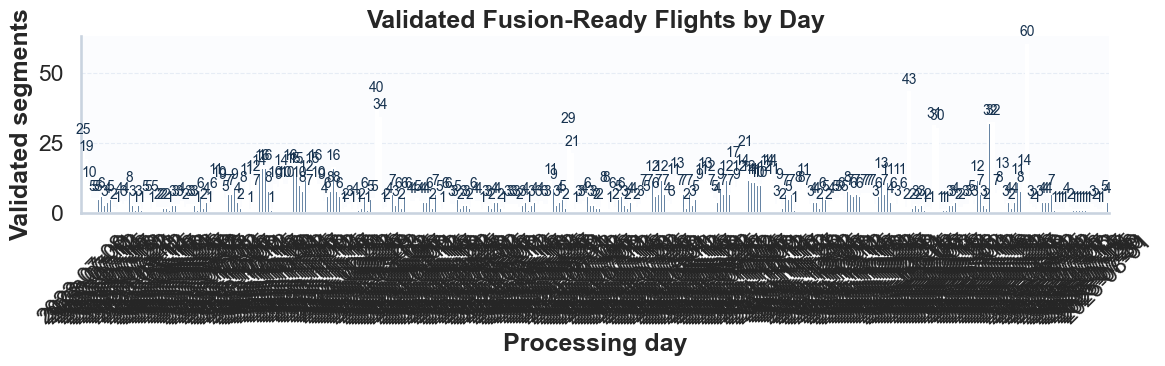

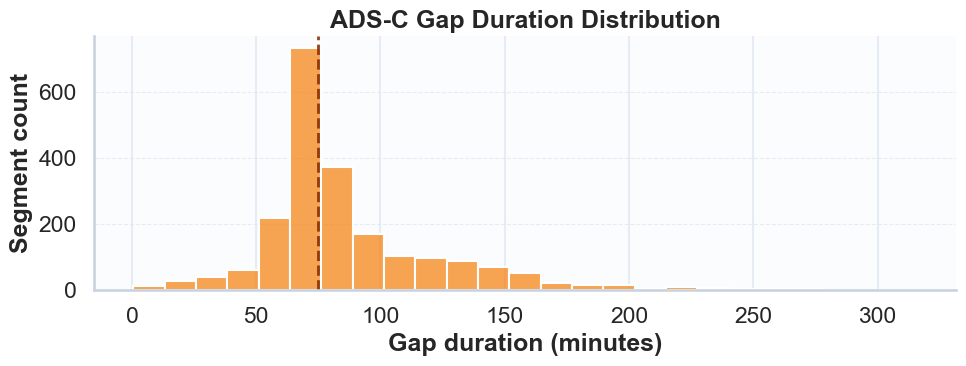

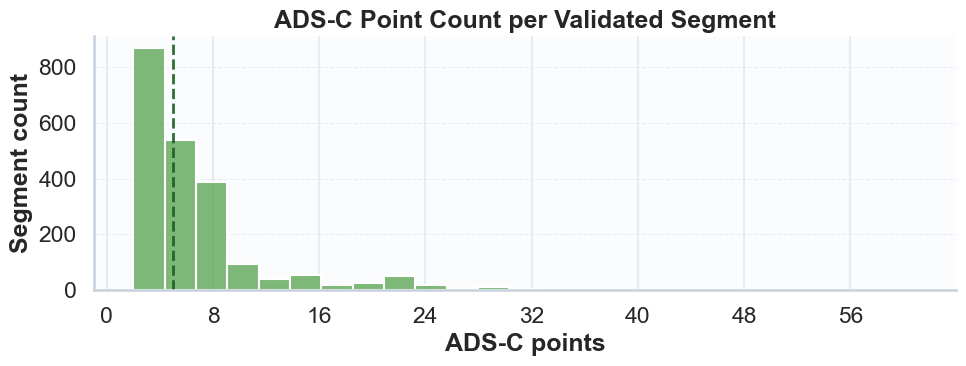

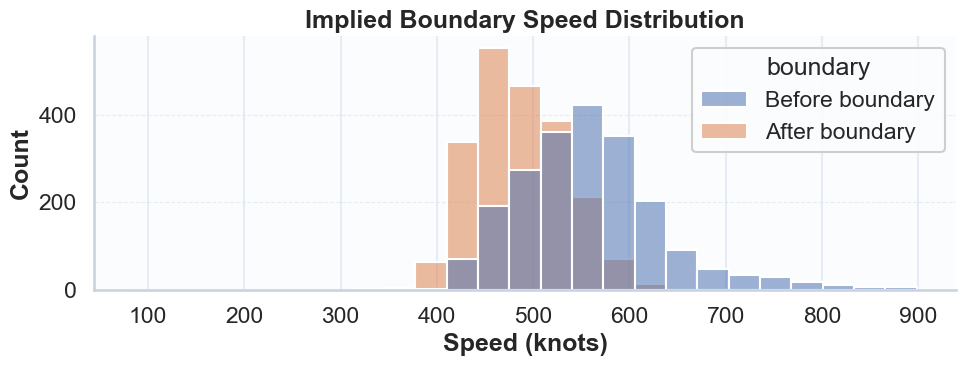

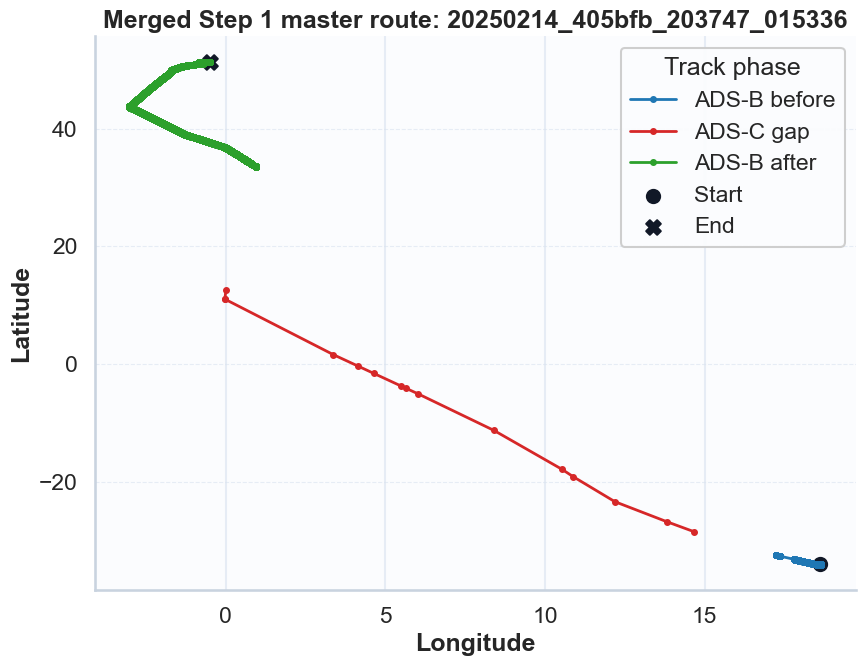

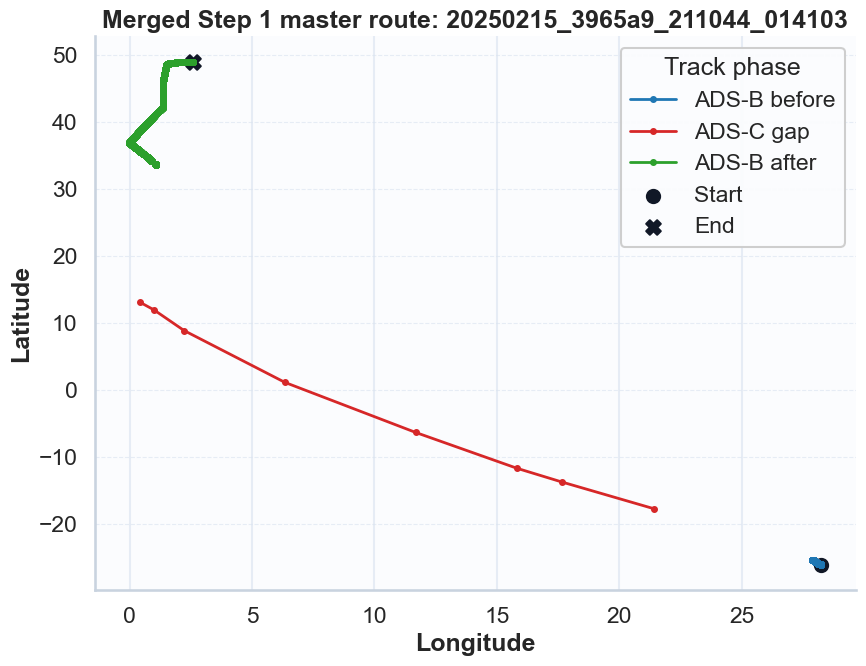

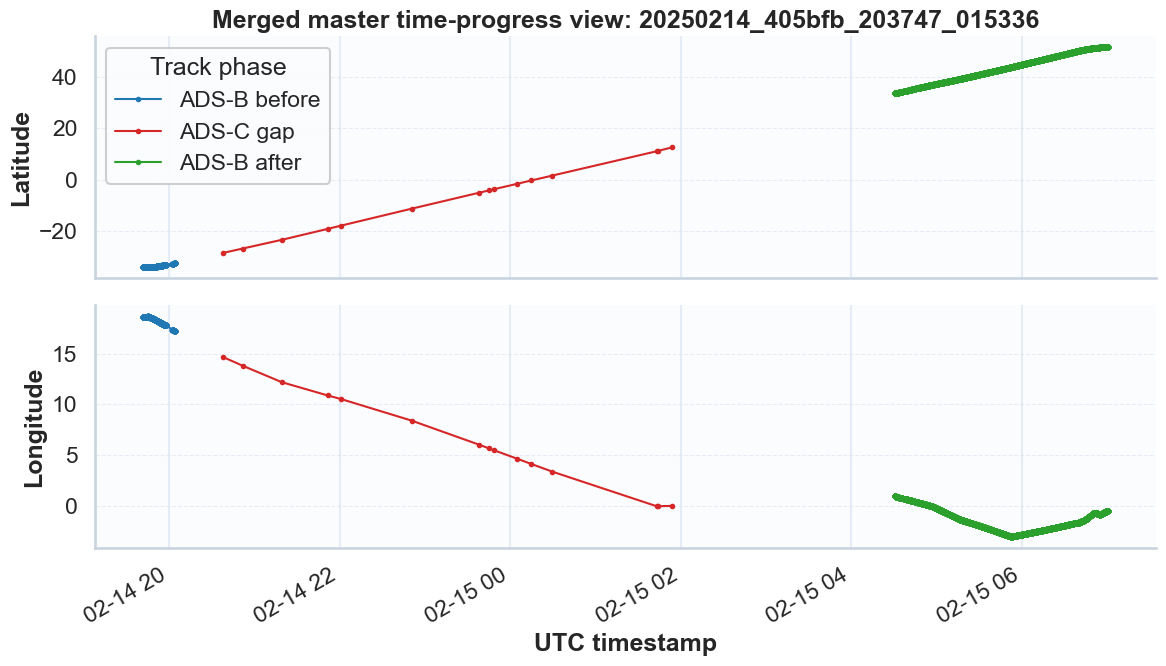

In [8]:
if master_df.empty:
    print("No merged Step 1 master dataset is available.")
else:
    plot_validated_flights_by_day(master_plot_df)
    plt.show()

    plot_gap_duration_hist(master_plot_df)
    plt.show()

    plot_adsc_point_count_hist(master_plot_df)
    plt.show()

    plot_boundary_speed_hist(master_plot_df)
    plt.show()

    merged_example_rows = master_plot_df.sort_values(["gap_duration_minutes", "adsc_point_count"], ascending=[False, False]).head(2)
    for row in merged_example_rows.itertuples(index=False):
        stitched_df = pd.read_parquet(row.master_stitched_minimal_path)
        plot_stitched_route(stitched_df, title=f"Merged Step 1 master route: {row.segment_id}")
        plt.show()

    merged_first_row = merged_example_rows.iloc[0]
    merged_adsc_df = pd.read_parquet(merged_first_row.master_adsc_path)
    merged_adsb_before_df = pd.read_parquet(merged_first_row.master_adsb_before_path)
    merged_adsb_after_df = pd.read_parquet(merged_first_row.master_adsb_after_path)
    plot_time_progress(
        adsb_before=merged_adsb_before_df,
        adsc_gap=merged_adsc_df,
        adsb_after=merged_adsb_after_df,
        title=f"Merged master time-progress view: {merged_first_row.segment_id}",
    )
    plt.show()
